<a href="https://colab.research.google.com/github/abeeraz379/Credit-Card-Applications-Prediction/blob/main/Credit_Card_Applications_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Applications Prediction
- By : ABeer Al-Zebda | Machine Learning Engineer

# Overview

**About Dataset**
💳 Credit Card Application Dataset
This dataset focuses on analyzing and predicting credit card approval decisions using real-world applicant data. It includes multiple customer attributes such as age, financial status, credit history, and employment details, which influence approval outcomes.

The dataset is ideal for building and evaluating machine learning models like Logistic Regression, Decision Trees, and Random Forests to classify whether an application will be approved or rejected.

**📊 Key Features**
- CustomerID: Unique identifier for each applicant
- A1 – A14: Customer attributes (demographics, financial status, credit behavior)
- A15: Target variable (Approval: Yes/No)

**🎯 Use Cases**
Credit risk analysis
Loan/credit approval prediction
Data preprocessing and feature engineering practice
Machine learning classification projects

**data link**
https://www.kaggle.com/datasets/nazishjaveed/credit-card-application

# Import Libraries

In [1]:
# import numpy ,pandas
# import test train split
# import logisticregression
# import Gridsearchcv
# import scaler
# import pipeline
# import onehot encoder
# import simple imbuter
# import confusion matrix , confusion report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix,classification_report
import warnings
warnings.filterwarnings('ignore')

# Load and Inspect data

In [2]:
df=pd.read_csv('/content/drive/MyDrive/ml specialization/Credit_Card_Applications.csv')
df.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


# Clean Data

In [4]:
df.isna().sum()

,0
CustomerID,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
for col in df.columns:
  print(col)
  print(df[col].unique())

CustomerID
[15776156 15739548 15662854 15687688 15715750 15571121 15726466 15660390
 15663942 15638610 15644446 15585892 15609356 15803378 15599440 15692408
 15683168 15790254 15767729 15768600 15699839 15786237 15694530 15796813
 15605791 15714087 15711446 15588123 15748552 15618410 15672432 15610042
 15580914 15583680 15813718 15767264 15686461 15678882 15789611 15668679
 15631685 15655658 15753591 15617348 15704581 15738487 15648069 15737627
 15731586 15757467 15597709 15720529 15596797 15681755 15815271 15682860
 15621546 15705918 15684512 15671769 15642934 15594305 15789201 15706762
 15766183 15777994 15568162 15680643 15761854 15730793 15692137 15608595
 15709459 15775750 15585855 15752139 15768295 15766906 15725776 15682576
 15704081 15719940 15672894 15667451 15636767 15571415 15575605 15649160
 15615832 15600975 15690772 15565714 15763108 15723884 15644453 15655464
 15783883 15787693 15664793 15642391 15756538 15668830 15796569 15677112
 15815040 15590434 15597536 15723989 157

# Preprocess

In [7]:
pd.set_option('display.max_columns',None)

In [8]:
# drop columns class and customerid FROM X and assign class to y
columns=['Class','CustomerID']
y = df[columns]
X = df.drop(columns=columns)

## train-test-split with random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)
X_train.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
647,1,26.17,0.835,2,13,4,1.165,0,0,0,0,2,100,1
163,1,34.50,4.040,1,3,5,8.500,1,1,7,1,2,195,1
380,1,39.08,6.000,2,7,4,1.290,1,1,5,1,2,108,1098
603,0,26.92,13.500,2,11,8,5.000,1,1,2,0,2,0,5001
432,0,30.58,10.665,2,11,8,0.085,0,1,12,1,2,129,4


In [9]:
# select numeric cols
num_cols = make_column_selector(dtype_include='number')

# make numeric pipeline
num_pipe = make_pipeline(SimpleImputer(strategy='mean'))

# numeric tuple
num_tuple =('numeric', num_pipe, num_cols)
# Create the Column Transformer
preprocessor = ColumnTransformer([num_tuple], verbose_feature_names_out=False)
preprocessor


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7f99241bab40>)],
                  verbose_feature_names_out=False)

In [10]:
## fit column transformer and run get_feature_names_out
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()


X_train_tf = pd.DataFrame(preprocessor.transform(X_train),
                          columns = feature_names, index = X_train.index)

X_test_tf = pd.DataFrame(preprocessor.transform(X_test),
                          columns = feature_names, index = X_test.index)
X_test_tf.head(3)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
286,1.0,65.42,11.00,2.0,10.0,9.0,20.000,1.0,1.0,7.0,1.0,2.0,22.0,1.0
511,1.0,18.17,10.25,2.0,8.0,8.0,1.085,0.0,0.0,0.0,0.0,2.0,320.0,14.0
257,1.0,48.50,4.25,2.0,7.0,4.0,0.125,1.0,0.0,0.0,1.0,2.0,225.0,1.0


# Build model

In [11]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [12]:
y_target = y_train.iloc[:, 0]

In [13]:
y_test2 = y_test.iloc[:, 0]

In [14]:
# import Catbosstclassifier
from catboost import CatBoostClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
# build catboostmodel

cbc=CatBoostClassifier(random_state=1,verbose=200 ,  l2_leaf_reg=2000)
pipe=make_pipeline(preprocessor,cbc)
pipe.fit(X_train_tf,y_target)

#evaluate
y_pred=pipe.predict(X_test_tf)
print(confusion_matrix(y_test2,y_pred))
print(classification_report(y_test2,y_pred))
print("accuracy Training:",pipe.score(X_train_tf,y_target))
print("accuracy Testing:",pipe.score(X_test_tf,y_test2))

0:	learn: 0.6924692	total: 47.6ms	remaining: 47.5s
200:	learn: 0.4935324	total: 431ms	remaining: 1.71s
400:	learn: 0.4390568	total: 1s	remaining: 1.49s
600:	learn: 0.4098542	total: 1.45s	remaining: 965ms
800:	learn: 0.3865783	total: 2.13s	remaining: 531ms
999:	learn: 0.3685640	total: 2.77s	remaining: 0us
[[94 13]
 [ 8 58]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       107
           1       0.82      0.88      0.85        66

    accuracy                           0.88       173
   macro avg       0.87      0.88      0.87       173
weighted avg       0.88      0.88      0.88       173

accuracy Training: 0.8858800773694391
accuracy Testing: 0.8786127167630058


# Model Insight

In [15]:
feature_names = preprocessor.get_feature_names_out()



In [16]:
feature_importance = pd.Series(cbc.feature_importances_, index=feature_names,
                        name='Feature Importances')
feature_importance.head()

,Feature Importances
A1,0.035146
A2,0.965719
A3,2.126193
A4,0.578212
A5,2.409370


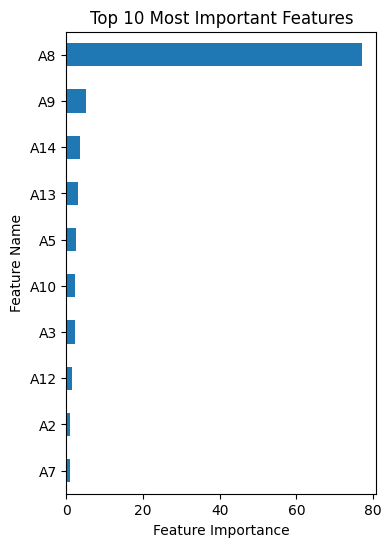

In [17]:
ax = feature_importance.sort_values().tail(10).plot(kind='barh',figsize=(4,6))
ax.set(ylabel='Feature Name',xlabel='Feature Importance',
       title='Top 10 Most Important Features');

## New model after take just the 10 important features

In [23]:
features= feature_importance.sort_values().tail(10)
features.tail(10)

,Feature Importances
A7,0.849234
A2,0.965719
A12,1.469619
A3,2.126193
A10,2.204799
A5,2.409370
A13,3.125218
A14,3.553341
A9,5.004090
A8,77.016445


In [24]:
X_train_preprocessed = preprocessor.fit_transform(X_train, y_train)
X_test_preprocessed = preprocessor.transform(X_test)


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

# Get indices of top 10 features
top10_indices = [i for i, name in enumerate(feature_names) if name in features]

# Manual selector using column indices
top10_selector = ColumnTransformer([
    ('top10', 'passthrough', top10_indices)
], remainder='drop')

# 5. Transform to top 10 features only
X_train_top10 = top10_selector.fit_transform(X_train)
X_test_top10 = top10_selector.transform(X_test)

print("New shapes:", X_train_top10.shape, X_test_top10.shape)

New shapes: (517, 10) (173, 10)


In [35]:
# build a cbc model use just the top 10 most important fratures and drop the rest and evaluate it
cbc_top10 = CatBoostClassifier(random_state=1, verbose=200)
cbc_top10.fit(X_train_top10, y_target)

y_pred_top10 = cbc_top10.predict(X_test_top10)
print(confusion_matrix(y_test2,y_pred_top10))
print(classification_report(y_test2,y_pred_top10))
print("accuracy Training:",pipe.score(X_train,y_target))
print("accuracy Testing:",pipe.score(X_test,y_test2))


Learning rate set to 0.007773
0:	learn: 0.6854728	total: 1.84ms	remaining: 1.83s
200:	learn: 0.2554827	total: 336ms	remaining: 1.33s
400:	learn: 0.1867323	total: 603ms	remaining: 901ms
600:	learn: 0.1507416	total: 896ms	remaining: 595ms
800:	learn: 0.1206118	total: 1.31s	remaining: 325ms
999:	learn: 0.0961418	total: 1.86s	remaining: 0us
[[99  8]
 [13 53]]
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       107
           1       0.87      0.80      0.83        66

    accuracy                           0.88       173
   macro avg       0.88      0.86      0.87       173
weighted avg       0.88      0.88      0.88       173

accuracy Training: 0.8858800773694391
accuracy Testing: 0.8786127167630058


In [41]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=1)
X_train_smote, y_train_smote = smote.fit_resample(X_train_top10, y_target)

cbc_top10 = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6,
                              l2_leaf_reg=1050, loss_function='Logloss',
                              eval_metric='AUC', random_seed=1, verbose=200)
cbc_top10.fit(X_train_smote, y_train_smote)


y_pred_top10 = cbc_top10.predict(X_test_top10)
print(confusion_matrix(y_test2,y_pred_top10))
print(classification_report(y_test2,y_pred_top10))
print("accuracy Training:",pipe.score(X_train,y_target))
print("accuracy Testing:",pipe.score(X_test,y_test2))

0:	total: 4.6ms	remaining: 4.59s
200:	total: 647ms	remaining: 2.57s
400:	total: 1.2s	remaining: 1.79s
600:	total: 1.61s	remaining: 1.07s
800:	total: 2.33s	remaining: 578ms
999:	total: 3.04s	remaining: 0us
[[94 13]
 [10 56]]
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       107
           1       0.81      0.85      0.83        66

    accuracy                           0.87       173
   macro avg       0.86      0.86      0.86       173
weighted avg       0.87      0.87      0.87       173

accuracy Training: 0.8858800773694391
accuracy Testing: 0.8786127167630058


**it gives a worse result, so i won't take it**